# Neural Networks: scikit-learn and Keras

This notebook introduces binary classification with the UCI Bank Marketing
sample. We predict whether a client subscribed to a term deposit (`y`) using
a reproducible 60/40 hold-out split. The workflow is:

1. validate and encode the tabular data;
2. scale features using training data only;
3. train an `MLPClassifier` baseline and tuned variants;
4. train the equivalent binary Keras model; and
5. compare accuracy, precision, recall, and F1 for the positive class.

Dataset source: [UCI Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank).


In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

keras.utils.set_random_seed(42)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RANDOM_STATE = 42
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "keras":
    PROJECT_DIR = PROJECT_DIR.parent
DATA_PATH = PROJECT_DIR / "input/bank-data.csv"
OUTPUT_DIR = PROJECT_DIR / "keras" / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"Keras {keras.__version__}; backend: {keras.config.backend()}")
assert DATA_PATH.exists(), f"Missing input file: {DATA_PATH}"


Keras 3.15.1; backend: tensorflow


## 1. Load and validate the data

The supplied file is the 4,521-row `bank.csv` subset. It uses semicolons as
separators. The target is binary: `yes` means that the client subscribed to
a term deposit, while `no` means that they did not.


In [2]:
EXPECTED_COLUMNS = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "balance",
    "housing",
    "loan",
    "contact",
    "day",
    "month",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "poutcome",
    "y",
]

raw = pd.read_csv(DATA_PATH, sep=";")
assert raw.shape == (4521, 17), raw.shape
assert raw.columns.tolist() == EXPECTED_COLUMNS
assert raw.isna().sum().sum() == 0
assert raw["y"].isin(["no", "yes"]).all()
assert raw["age"].between(18, 100).all()
assert raw["day"].between(1, 31).all()
assert raw["duration"].ge(0).all()

print(f"Rows: {len(raw):,}; columns: {raw.shape[1]}")
print("Target counts:")
display(raw["y"].value_counts().rename_axis("subscription").to_frame("count"))
display(raw.head())


Rows: 4,521; columns: 17
Target counts:


,count
subscription,
no,4000
yes,521


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## 2. Preprocess the features

Binary columns are label-encoded. The remaining categorical columns are
one-hot encoded. The target mapping is checked explicitly so that class `1`
always means `yes`.


In [3]:
binary_columns = ["y", "default", "housing", "loan"]
encoded = raw.copy()
encoding_maps = {}

for column in binary_columns:
    encoder = LabelEncoder()
    encoded[column] = encoder.fit_transform(encoded[column])
    encoding_maps[column] = dict(
        zip(encoder.classes_, encoder.transform(encoder.classes_))
    )

assert encoding_maps["y"] == {"no": 0, "yes": 1}
display(pd.DataFrame(encoding_maps).fillna(""))


,y,default,housing,loan
no,0,0,0,0
yes,1,1,1,1


In [4]:
categorical_columns = [
    "job",
    "marital",
    "education",
    "contact",
    "month",
    "poutcome",
]

encoded = pd.get_dummies(
    encoded,
    columns=categorical_columns,
    dtype=np.int64,
)
assert encoded.select_dtypes(exclude=np.number).empty
print(f"Encoded table shape: {encoded.shape}")
display(encoded.head())


Encoded table shape: (4521, 49)


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,30,0,1787,0,0,19,79,1,-1,0,...,0,0,0,0,1,0,0,0,0,1
1,33,0,4789,1,1,11,220,1,339,4,...,0,0,1,0,0,0,1,0,0,0
2,35,0,1350,1,0,16,185,1,330,1,...,0,0,0,0,0,0,1,0,0,0
3,30,0,1476,1,1,3,199,4,-1,0,...,1,0,0,0,0,0,0,0,0,1
4,59,0,0,1,0,5,226,1,-1,0,...,0,0,1,0,0,0,0,0,0,1


### 2.1 Train/test separation and feature scaling

The test set is held out before scaling. `StandardScaler` learns its mean and
standard deviation from `X_train` only, preventing test-set information from
leaking into training.


In [5]:
X = encoded.drop(columns="y")
y = encoded["y"].astype("int64")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE,
)
assert X_train.shape == (2712, 48)
assert X_test.shape == (1809, 48)
assert y_train.value_counts().to_dict() == {0: 2399, 1: 313}
assert y_test.value_counts().to_dict() == {0: 1601, 1: 208}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
assert np.isfinite(X_train_scaled).all()
assert np.isfinite(X_test_scaled).all()
print(f"X_train: {X_train_scaled.shape}; X_test: {X_test_scaled.shape}")


X_train: (2712, 48); X_test: (1809, 48)


## 3. Artificial neural network with scikit-learn

`MLPClassifier` is a multilayer perceptron. The baseline has three hidden
layers with ten units each, matching the supplied lab starter. Early stopping
uses a validation portion of the training set and restores the best weights.


In [6]:
mlp = MLPClassifier(
    hidden_layer_sizes=(10, 10, 10),
    activation="relu",
    solver="adam",
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=25,
    random_state=RANDOM_STATE,
)
mlp.fit(X_train_scaled, y_train)
mlp_predictions = mlp.predict(X_test_scaled)
print(f"Training iterations: {mlp.n_iter_}")


Training iterations: 41


              precision    recall  f1-score   support

          no       0.89      0.98      0.93      1601
         yes       0.37      0.08      0.13       208

    accuracy                           0.88      1809
   macro avg       0.63      0.53      0.53      1809
weighted avg       0.83      0.88      0.84      1809



,model,accuracy,precision_yes,recall_yes,f1_yes
0,sklearn MLP baseline,0.8784,0.3696,0.0817,0.1339


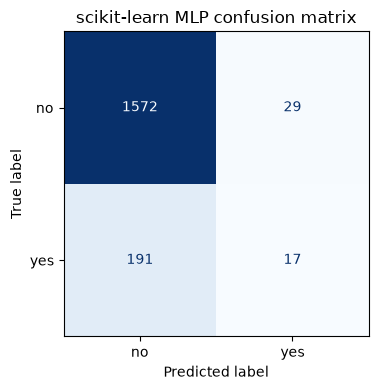

In [7]:
def binary_metric_row(name, truth, predictions):
    return {
        "model": name,
        "accuracy": accuracy_score(truth, predictions),
        "precision_yes": precision_score(
            truth, predictions, pos_label=1, zero_division=0
        ),
        "recall_yes": recall_score(
            truth, predictions, pos_label=1, zero_division=0
        ),
        "f1_yes": f1_score(
            truth, predictions, pos_label=1, zero_division=0
        ),
    }

mlp_metrics = pd.DataFrame(
    [binary_metric_row("sklearn MLP baseline", y_test, mlp_predictions)]
)
print(classification_report(y_test, mlp_predictions, target_names=["no", "yes"], zero_division=0))
display(mlp_metrics.round(4))

cm = confusion_matrix(y_test, mlp_predictions, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["no", "yes"]).plot(
    ax=ax, cmap="Blues", values_format="d", colorbar=False
)
ax.set_title("scikit-learn MLP confusion matrix")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "bank_mlp_confusion_matrix.png", dpi=150)
display(fig)
plt.close(fig)


## 4. Model tuning

Accuracy alone can hide poor detection of the minority `yes` class. We compare
hidden-layer size, regularization, batch size, and learning rate using the same
split and the same four metrics.


In [8]:
tuning_settings = {
    "smaller + regularized": {
        "hidden_layer_sizes": (16, 8),
        "alpha": 0.001,
        "batch_size": 64,
        "learning_rate_init": 0.001,
    },
    "wider + slower": {
        "hidden_layer_sizes": (64, 32),
        "alpha": 0.0001,
        "batch_size": 64,
        "learning_rate_init": 0.0005,
    },
    "wider + faster": {
        "hidden_layer_sizes": (64, 32),
        "alpha": 0.0001,
        "batch_size": 128,
        "learning_rate_init": 0.002,
    },
}

tuning_rows = [binary_metric_row("sklearn MLP baseline", y_test, mlp_predictions)]
for name, settings in tuning_settings.items():
    candidate = MLPClassifier(
        activation="relu",
        solver="adam",
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=25,
        random_state=RANDOM_STATE,
        **settings,
    )
    candidate.fit(X_train_scaled, y_train)
    predictions = candidate.predict(X_test_scaled)
    tuning_rows.append(binary_metric_row(name, y_test, predictions))

sklearn_comparison = (
    pd.DataFrame(tuning_rows)
    .sort_values("f1_yes", ascending=False)
    .reset_index(drop=True)
)
sklearn_comparison.to_csv(OUTPUT_DIR / "bank_sklearn_metrics.csv", index=False)
display(sklearn_comparison.round(4))
best_sklearn = sklearn_comparison.iloc[0]
print(
    f"Best F1 for yes: {best_sklearn['model']} "
    f"(F1={best_sklearn['f1_yes']:.4f})."
)


,model,accuracy,precision_yes,recall_yes,f1_yes
0,wider + slower,0.8872,0.5323,0.1587,0.2444
1,wider + faster,0.8856,0.5079,0.1538,0.2362
2,smaller + regularized,0.8850,0.5000,0.1154,0.1875
3,sklearn MLP baseline,0.8784,0.3696,0.0817,0.1339


Best F1 for yes: wider + slower (F1=0.2444).


## 5. Equivalent binary classifier with Keras

Keras 3 expects samples in the first dimension: `(n_samples, n_features)`.
The old starter's `expand_dims` would turn the data into a single sample with
many time steps, so it is intentionally removed. An explicit `Input` layer
also avoids the deprecated `input_shape` argument on `Dense`.


In [9]:
keras.utils.set_random_seed(RANDOM_STATE)
nn = keras.Sequential(
    [
        keras.Input(shape=(X_train_scaled.shape[1],), name="features"),
        keras.layers.Dense(48, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ],
    name="bank_binary_mlp",
)
nn.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
nn.summary()


Model: "bank_binary_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 48)             │         2,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,401 (9.38 KB)

 Trainable params: 2,401 (9.38 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = nn.fit(
    X_train_scaled,
    y_train.to_numpy(),
    validation_split=0.10,
    epochs=100,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
        )
    ],
    verbose=0,
)

history_frame = pd.DataFrame(history.history)
display(history_frame.tail())


,accuracy,loss,val_accuracy,val_loss
39,0.9078,0.2343,0.8676,0.3141
40,0.9082,0.2333,0.8676,0.3142
41,0.9086,0.2324,0.8676,0.3143
42,0.9094,0.2316,0.8676,0.3144
43,0.9094,0.2307,0.8676,0.3145


In [11]:
keras_eval = nn.evaluate(X_test_scaled, y_test.to_numpy(), verbose=0, return_dict=True)
keras_probabilities = nn.predict(X_test_scaled, verbose=0).ravel()
keras_predictions = (keras_probabilities >= 0.5).astype("int64")
keras_metrics = pd.DataFrame(
    [binary_metric_row("Keras binary MLP", y_test, keras_predictions)]
)
keras_metrics["loss"] = keras_eval["loss"]
keras_metrics.to_csv(OUTPUT_DIR / "bank_keras_metrics.csv", index=False)
print(classification_report(y_test, keras_predictions, target_names=["no", "yes"], zero_division=0))
display(keras_metrics.round(4))


              precision    recall  f1-score   support

          no       0.91      0.98      0.94      1601
         yes       0.62      0.25      0.36       208

    accuracy                           0.90      1809
   macro avg       0.76      0.62      0.65      1809
weighted avg       0.88      0.90      0.88      1809



,model,accuracy,precision_yes,recall_yes,f1_yes,loss
0,Keras binary MLP,0.8961,0.6163,0.2548,0.3605,0.2658


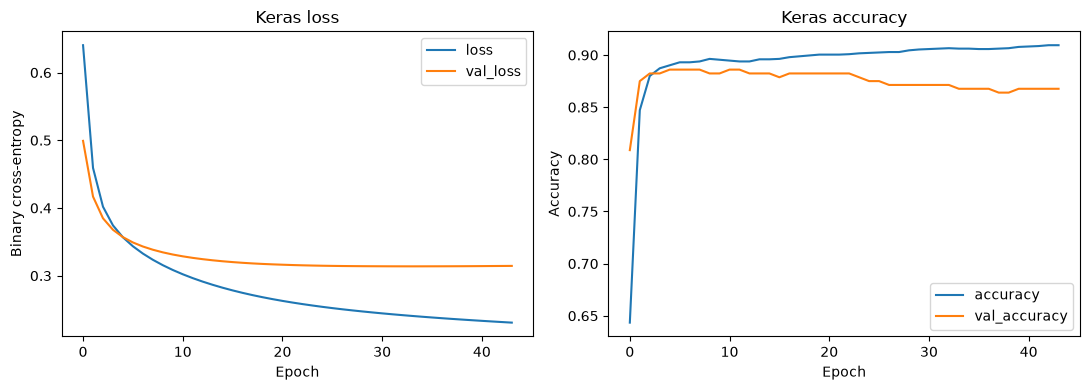

,model,accuracy,precision_yes,recall_yes,f1_yes
0,wider + slower,0.8872,0.5323,0.1587,0.2444
1,wider + faster,0.8856,0.5079,0.1538,0.2362
2,smaller + regularized,0.8850,0.5000,0.1154,0.1875
3,sklearn MLP baseline,0.8784,0.3696,0.0817,0.1339
4,Keras binary MLP,0.8961,0.6163,0.2548,0.3605


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
history_frame[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_title("Keras loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
history_frame[["accuracy", "val_accuracy"]].plot(ax=axes[1])
axes[1].set_title("Keras accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "bank_keras_history.png", dpi=150)
display(fig)
plt.close(fig)

comparison = pd.concat(
    [sklearn_comparison, keras_metrics.drop(columns="loss")],
    ignore_index=True,
)
display(comparison.round(4))


## Conclusion

The positive class is the minority outcome, so report the `yes` precision,
recall, and F1 alongside accuracy. Changing preprocessing and optimizer/model
settings can improve a metric without improving every metric. These models
describe predictive association; they do not establish that a customer
characteristic causes subscription behavior.
